In [237]:
# test Drift alogorithm on temperature-Talin

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

data = np.loadtxt("Talin_temperature.txt", skiprows=1)
t = data[:, 0]
x = data[:, 1]
dt = 8.494e-4#[s] 

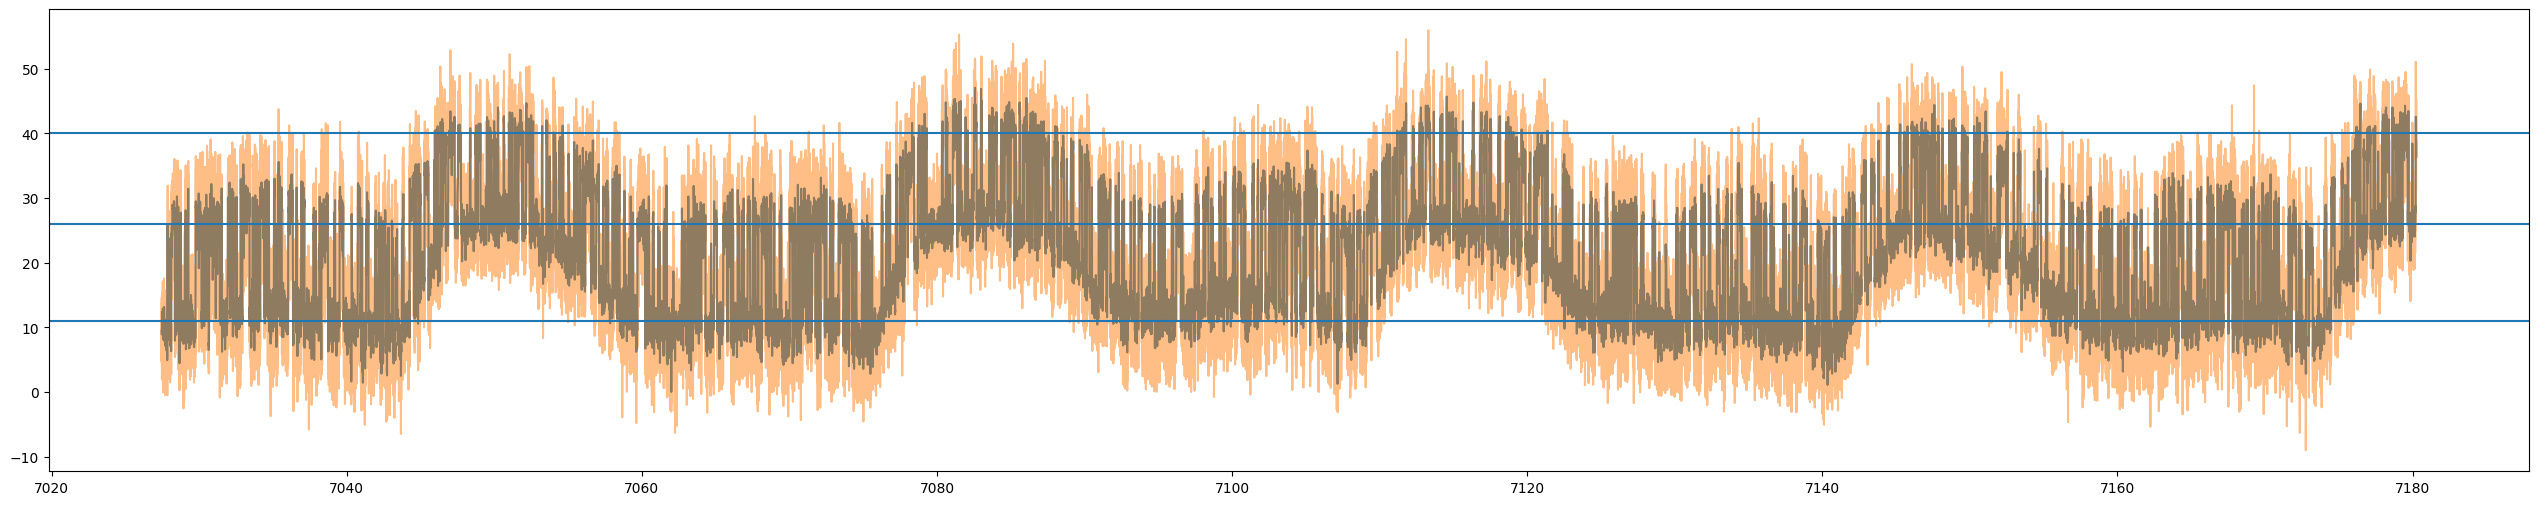

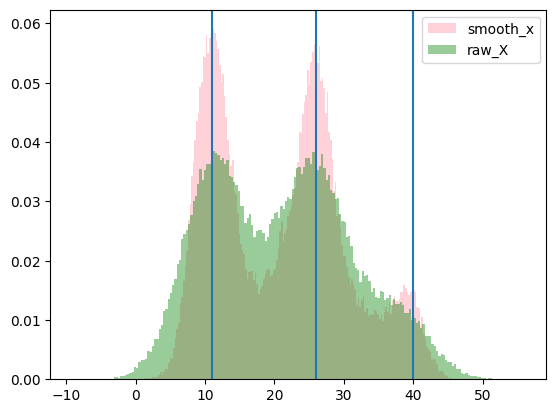

In [38]:

x_smooth = savgol_filter(x, window_length = 21, polyorder= 2)
p,q = 0, len(x)
plt.figure(figsize=(32,6))
plt.plot(t[p:q], x_smooth[p:q])
plt.plot(t[p:q], x[p:q], label = "raw data", alpha=0.5)
plt.axhline(y = 11);plt.axhline(y = 40);plt.axhline(y = 26)
plt.show()

plt.hist(x_smooth, bins = 200, density = True, alpha = 0.7, color="pink", label="smooth_x")
plt.hist(x, bins = 200, density = True, alpha = 0.4, color="green", label="raw_X"); plt.legend()
plt.axvline(x = 11);plt.axvline(x = 40);plt.axvline(x = 26)



# m,n = [34.1429672, 57.94641481]
# plt.axvline(x = m); plt.axvline(x= n)

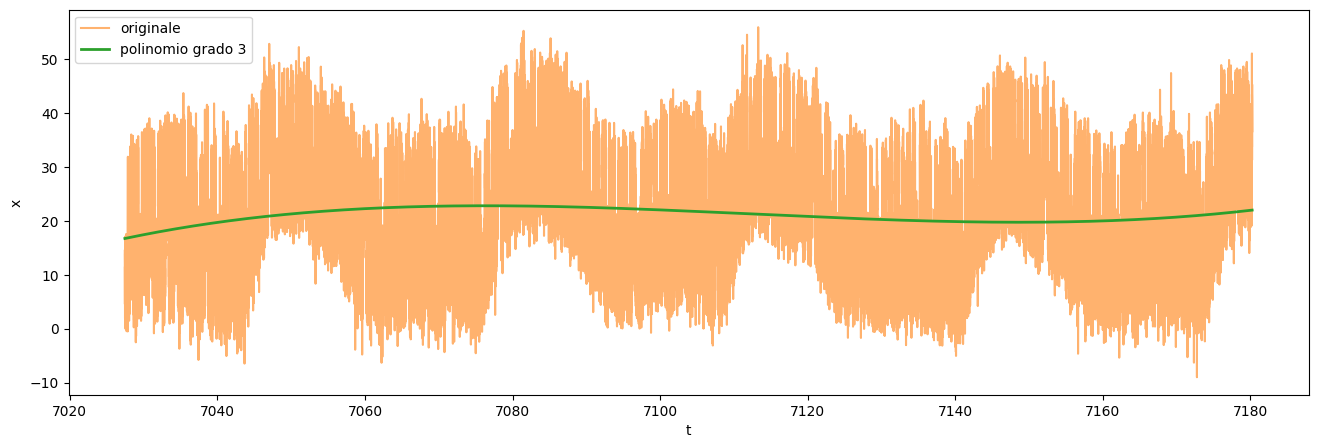

In [238]:

grado = 3
coeff = np.polyfit(t, x, grado)
drift = np.polyval(coeff, t)
x_detrended = x - drift
x_smooth = savgol_filter(x, window_length = 41, polyorder= 2)

# controllo
plt.figure(figsize=(16,5))
plt.plot(t[p:q], x_smooth[p:q])

plt.plot(t, x,     label="originale", alpha=0.6)
plt.plot(t, drift, label=f"polinomio grado {grado}", lw=2)
plt.legend(); plt.xlabel("t"); plt.ylabel("x")
plt.show()



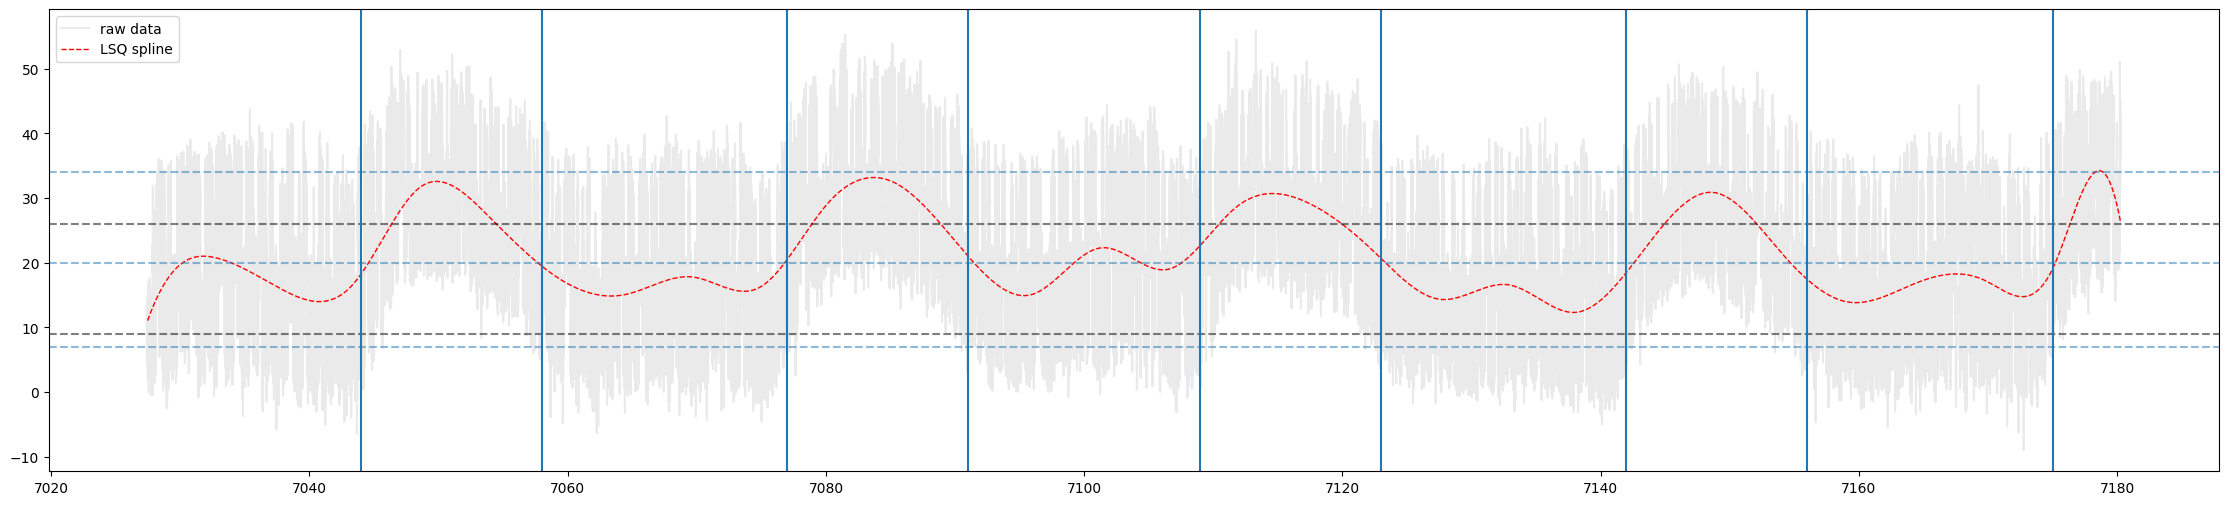

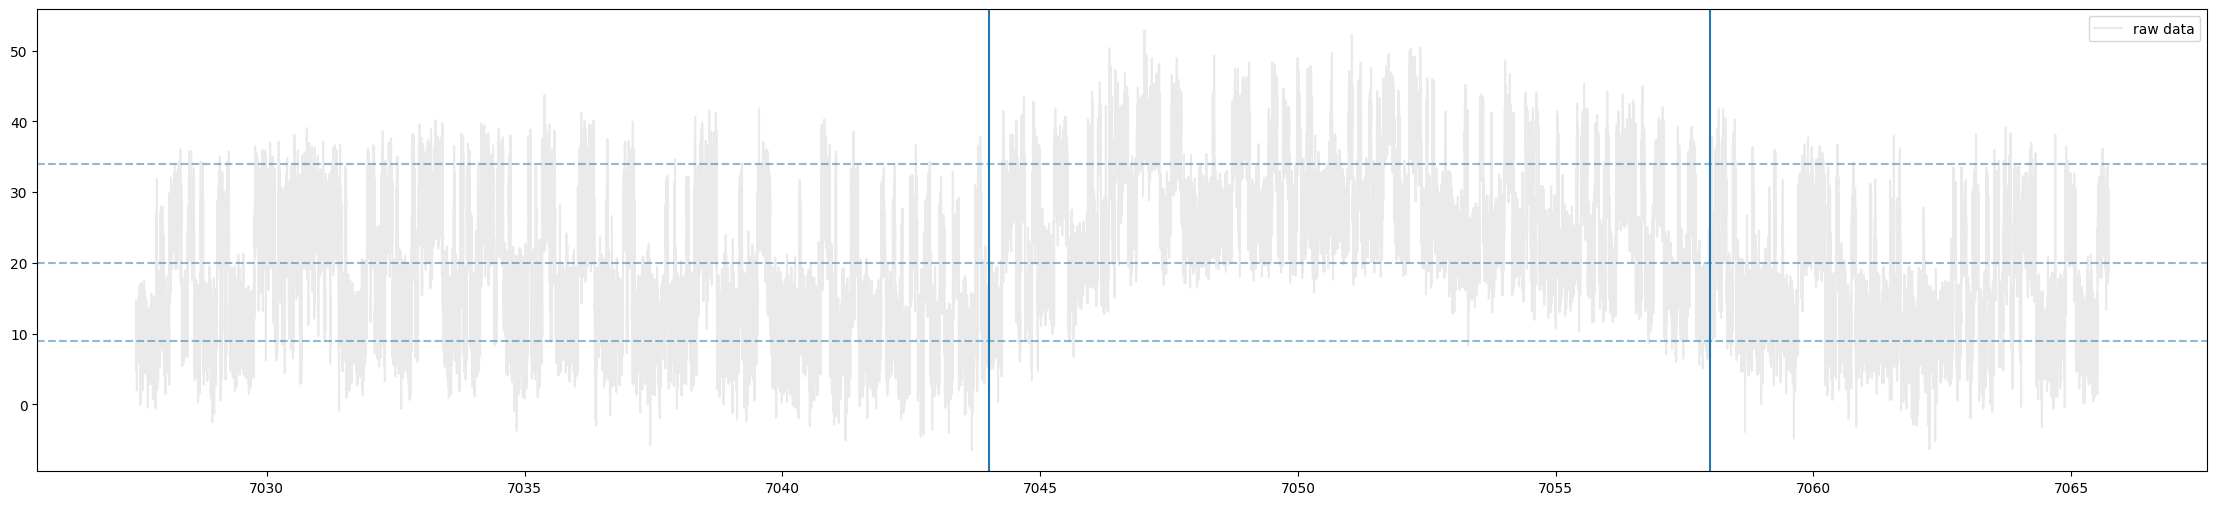

In [ ]:

from scipy.interpolate import LSQUnivariateSpline

# t, x già definiti
# decido di mettere K nodi equispaziati nell’intervallo
K = 30
knots = np.linspace(t.min(), t.max(), K)[1:-1]  # escludo gli estremi

# spline di grado 3 che minimizza i residui globali
spl = LSQUnivariateSpline(t, x, t=knots, k=3)
x_fit = spl(t)

p=len(x)
plt.figure(figsize=(28,6))
plt.plot(t[0:p], x[0:p],    color='0.8', alpha=0.4, label='raw data')
plt.plot(t[:p], x_fit[:p], lw=1, color="red", label='LSQ spline', linestyle="--")
plt.axhline(y = 20, linestyle="--", alpha=0.5);plt.axhline(y = 34,linestyle="--", alpha=0.5);plt.axhline(y = 7, linestyle="--", alpha=0.5)
plt.axhline(y = 26, linestyle="--", alpha=0.5, c="black");plt.axhline(y = 9,linestyle="--", alpha=0.5, c="black")

# 19sec vs 14sec
plt.axvline(x = 7044), plt.axvline(x = 7058);plt.axvline(x = 7077); plt.axvline(x = 7091); plt.axvline(x = 7109); plt.axvline(x = 7123);  plt.axvline(x = 7142); plt.axvline(x = 7156); plt.axvline(x = 7175)
plt.legend(); plt.show()

plt.figure(figsize=(28,6))
plt.plot(t[0:int(2*p/8)], x[0:int(2*p/8)],    color='0.8', alpha=0.4, label='raw data')
# plt.plot(t[:int(2*p/8)], x_fit[:int(2*p/8)], 'C1', lw=2,       label='LSQ spline')
# plt.axhline(y = 11, linestyle="--", alpha=0.5);plt.axhline(y = 40 ,linestyle="--", alpha=0.5);plt.axhline(y = 26, linestyle="--", alpha=0.5)
plt.axhline(y = 20, linestyle="--", alpha=0.5);plt.axhline(y = 34,linestyle="--", alpha=0.5);plt.axhline(y = 9, linestyle="--", alpha=0.5)
# plt.axhline(y = 26, linestyle="--", alpha=0.5, c="black");plt.axhline(y = 9,linestyle="--", alpha=0.5, c="black")
plt.axvline(x = 7044), plt.axvline(x = 7058)


plt.legend(); plt.show()


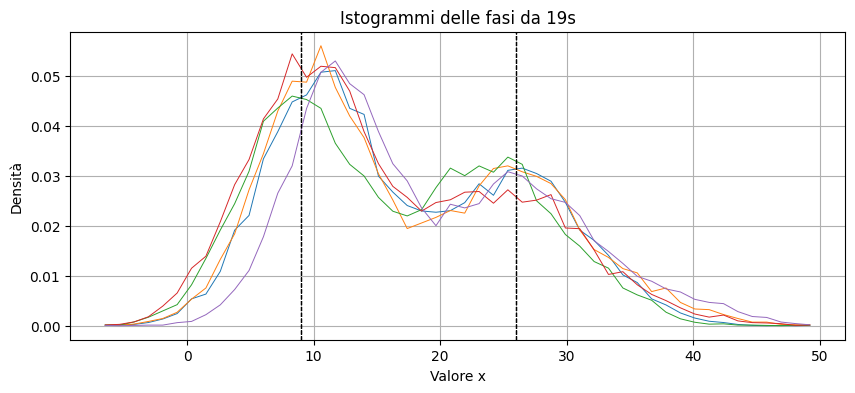

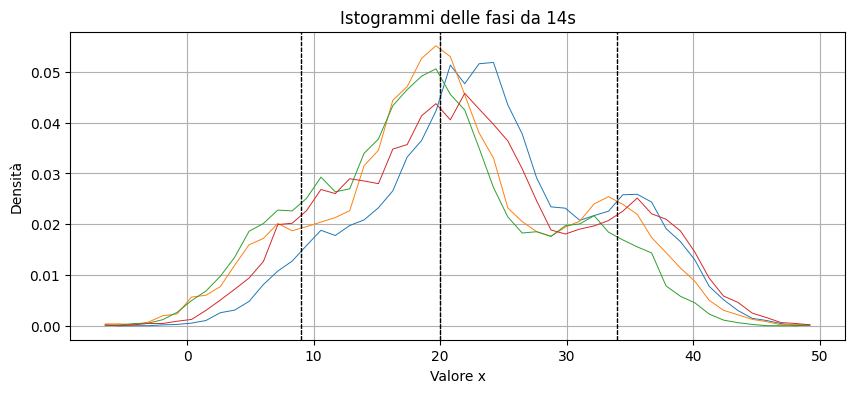

In [211]:
durate = [19, 14]         # alternanza
t0 = t[0]                 # tempo iniziale
N_blocchi = 9            # numero totale di blocchi da analizzare

hists_19 = []
hists_14 = []
bin_edges = None

for i in range(N_blocchi):
    dur = durata = durate[i % 2]
    t_start = t0 + sum(durate[j % 2] for j in range(i))
    t_end = t_start + durata

    mask = (t >= t_start) & (t < t_end)
    dati = x[mask]

    hist, edges = np.histogram(dati, bins=50, density=True)
    if bin_edges is None:
        bin_edges = edges

    if durata == 19:
        hists_19.append(hist)
    else:
        hists_14.append(hist)

plt.figure(figsize=(10, 4))
for i, h in enumerate(hists_19):
    plt.plot(bin_edges[:-1], h, label=f"19s – Blocco {i+1}", lw=0.7)
    plt.axvline(x = 9, linestyle="--", lw = 0.8, c="black");plt.axvline(x = 26, linestyle="--", lw = 0.8, c="black")

plt.title("Istogrammi delle fasi da 19s")
plt.xlabel("Valore x")
plt.ylabel("Densità")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
for i, h in enumerate(hists_14):
    plt.plot(bin_edges[:-1], h, label=f"14s – Blocco {i+1}", lw=0.7)
    plt.axvline(x = 20, linestyle="--", lw = 0.8, c="black");plt.axvline(x = 34, linestyle="--", lw = 0.8, c="black");plt.axvline(x = 9, linestyle="--", lw = 0.8, c="black")

plt.title("Istogrammi delle fasi da 14s")
plt.xlabel("Valore x")
plt.ylabel("Densità")
plt.grid(True)
plt.show()


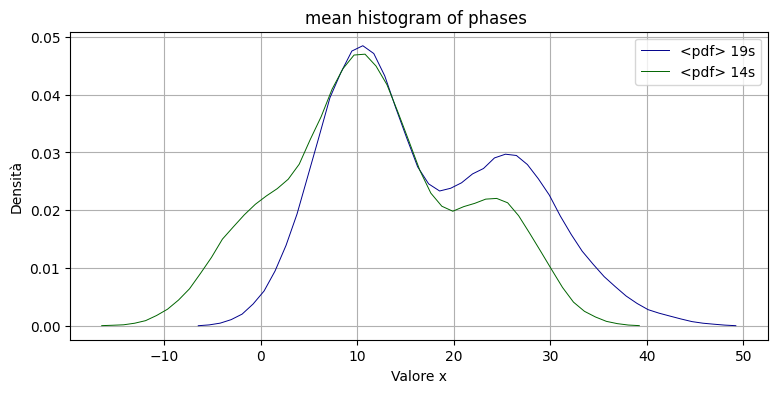

In [198]:
def smooth(y, w=3):
    return np.convolve(y, np.ones(w)/w, mode='same')  # media mobile

hist_mean_19 = np.mean(hists_19, axis=0)
hist_mean_14 = np.mean(hists_14, axis=0)
hist_smooth_19 = smooth(hist_mean_19, w=3)
hist_smooth_14 = smooth(hist_mean_14, w=3)

plt.figure(figsize=(9, 4))
plt.plot(bin_edges[:-1], hist_smooth_19, color='darkblue', lw=0.7, label='<pdf> 19s')
plt.title("Istogramma medio delle fasi da 19s")
plt.xlabel("Valore x")
plt.ylabel("Densità")
plt.grid(True)
plt.legend()

plt.plot(bin_edges[:-1]-10, hist_smooth_14, color='darkgreen', lw=0.7, label='<pdf> 14s')
plt.title("mean histogram of phases ")
plt.xlabel("Valore x")
plt.ylabel("Densità")
plt.grid(True)
plt.legend()



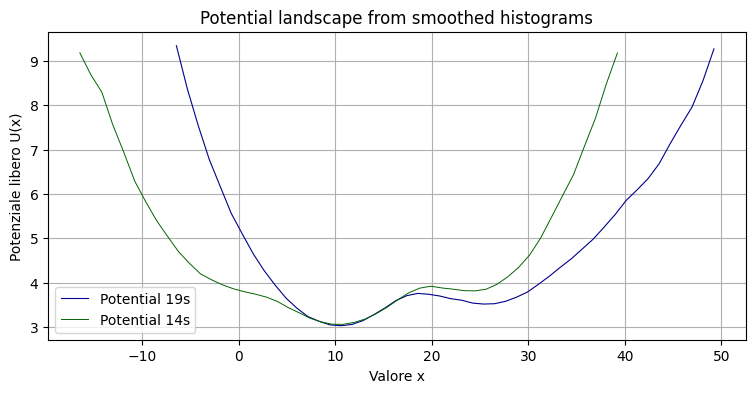

In [202]:
# Calcolo del potenziale libero: U(x) = -log(P(x))
def compute_potential(density, epsilon=1e-10):
    return -np.log(density + epsilon)

# Ricostruzione dei potenziali
U_19 = compute_potential(hist_smooth_19)
U_14 = compute_potential(hist_smooth_14)

# Plot del landscape del potenziale
plt.figure(figsize=(9, 4))
plt.plot(bin_edges[:-1], U_19, color='darkblue', lw=0.8, label='Potential 19s')
plt.plot(bin_edges[:-1]-10, U_14, color='darkgreen', lw=0.7, label='Potential 14s')
plt.title("Potential landscape from smoothed histograms")
plt.xlabel("Valore x")
plt.ylabel("Potenziale libero U(x)")
plt.grid(True)
plt.legend()
plt.show()


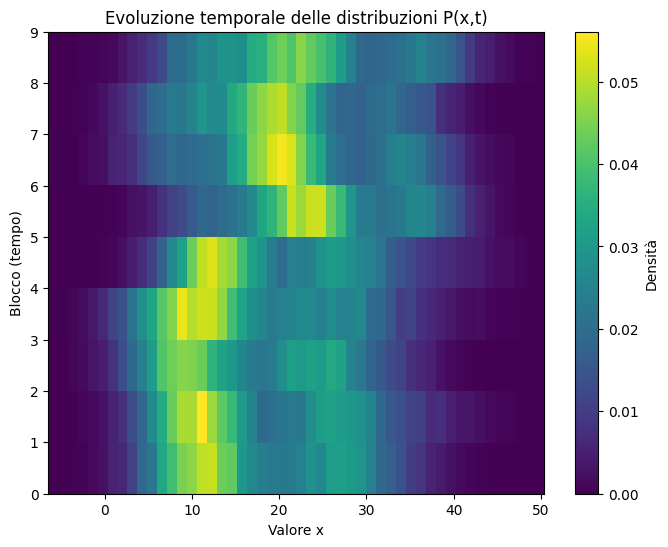

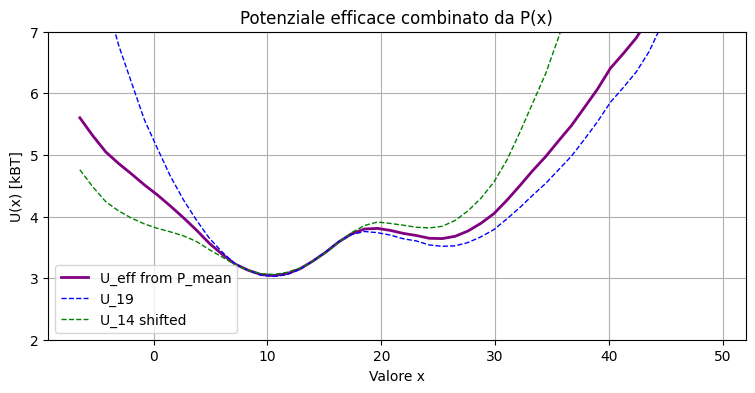

In [232]:
# Costruisci matrice densità P(x, t)
all_hists = hists_19 + hists_14
time_labels = np.arange(len(all_hists)) * (14 + 19)/2  # o tempo reale
hist_matrix = np.array(all_hists)

plt.figure(figsize=(8, 6))
plt.imshow(hist_matrix, aspect='auto', origin='lower', extent=[bin_edges[0], bin_edges[-1], 0, len(all_hists)],
           cmap='viridis')
plt.colorbar(label='Densità')
plt.xlabel('Valore x')
plt.ylabel('Blocco (tempo)')
plt.title('Evoluzione temporale delle distribuzioni P(x,t)')
plt.show()

# Media pesata dei due potenziali, se vuoi "fondere"

P_19 = hist_smooth_19
P_14 = hist_smooth_14

# Supponiamo che bin_edges[:-1] siano le x associate a P_19
# E vogliamo traslare P_14 di +8 unità a destra sull'asse x
x = bin_edges[:-1]  # posizione dei bin

# Interpolazione di P_14 (traslata di 8)
from scipy.interpolate import interp1d

interp_P14 = interp1d(x - 10, P_14, bounds_error=False, fill_value=0.0)
P_14_shifted = interp_P14(x)

# Media pesata
alpha = 19 / (19 + 14)
P_eff = alpha * P_19 + (1 - alpha) * P_14_shifted

# Calcolo del potenziale efficace
epsilon = 1e-12
U_eff = -np.log(P_eff + epsilon)

# Plot
plt.figure(figsize=(9, 4))
plt.plot(x, U_eff, lw=2, color='purple', label='U_eff from P_mean')
plt.plot(x, -np.log(P_19 + epsilon), lw=1, ls='--', color='blue', label='U_19')
plt.plot(x, -np.log(P_14_shifted + epsilon), lw=1, ls='--', color='green', label='U_14 shifted')
plt.ylim(2,7)
plt.xlabel("Valore x")
plt.ylabel("U(x) [kBT]")
plt.title("Potenziale efficace combinato da P(x)")
plt.legend()
plt.grid(True)
plt.show()


In [234]:
# rate 
# MFPT rate : Talin vs FAK


from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

def mfpt_analysis(x, U, D, prominence=0.4, width=20, distance=20):

    mask = np.isfinite(U)  # True dove G1 è un numero valido
    bin_c_clean = x[mask]
    U_clean = U[mask]

    U_interp = interp1d(bin_c_clean, U_clean, kind='cubic', fill_value='extrapolate')

    # 3) Trova minima e barriera
    min_idx, _ = find_peaks(-U, prominence=prominence, width=width, distance=distance)
    max_idx, _ = find_peaks(U,  prominence=prominence, width=width, distance=distance)

    x_folded   = x[min_idx[0]]
    x_unfolded = x[min_idx[1]]
    x_barrier  = x[max_idx]

    print("Minima idx:", min_idx, "→", x_folded, x_unfolded)
    print("Barriera idx:", max_idx, "→", x_barrier)
    print("U(minima):", U_interp([x_folded, x_unfolded]),
          "U(barriera):", U_interp(x_barrier))

#---------------------------------------------------
    def mfpt(U_interp,x, x_a, x_b, D):
        def inner_integral(y):
            result, _ = quad(lambda z: np.exp(-(U_interp(z) - U_interp(x_a))), x_a, y, limit=1000)
            return result

        def outer_integral():
            result, _ = quad(lambda y: np.exp(U_interp(y) - U_interp(x_a)) * inner_integral(y), x, x_b, limit=1000)
            return result

        return outer_integral() / D


    
    print(f"x_folded: {x_folded}, x_unfolded: {x_unfolded}, x_barrier: {x_barrier}")
    print(f"U(x_folded): {U_interp(x_folded)}, U(x_unfolded): {U_interp(x_unfolded)}, U(x_barrier): {U_interp(x_barrier)}")

    mfpt_fold = mfpt(U_interp, x_folded, x_folded - 4.5, x_unfolded, D=D)
    mfpt_unfold = mfpt(U_interp, x_unfolded, x_unfolded + 4.5, x_folded, D=D)

    rate_unfolding   = 1 / mfpt_fold   if mfpt_fold   > 0 else np.nan
    rate_folding = 1 / mfpt_unfold if mfpt_unfold > 0 else np.nan

    print(f"Rate Folding:   {rate_folding:.4e} s⁻¹")
    print(f"Rate Unfolding: {rate_unfolding:.4e} s⁻¹")

    plt.figure(figsize=(8,5))
    plt.plot(bin_c_clean, U_interp(bin_c_clean),  label='U(x)', linewidth=2); plt.ylim(3,4)
    plt.scatter([x_folded, x_unfolded], [U_interp(x_folded), U_interp(x_unfolded)],
                c='green', label='Minima')
    plt.scatter([x_barrier],[U_interp(x_barrier)], c='red', label='Barriera')
    plt.xlabel('x')
    plt.ylabel('U(x) [kT]')
    plt.grid(True)
    plt.show()

    return rate_folding, rate_unfolding


Minima idx: [15 28] → 10.575664600000001 25.35141572
Barriera idx: [23] → [19.66843452]
U(minima): [3.04080181 3.64175519] U(barriera): [3.80725427]
x_folded: 10.575664600000001, x_unfolded: 25.35141572, x_barrier: [19.66843452]
U(x_folded): 3.040801809953605, U(x_unfolded): 3.6417551895831854, U(x_barrier): [3.80725427]
Rate Folding:   2.1049e+01 s⁻¹
Rate Unfolding: 1.2168e+01 s⁻¹


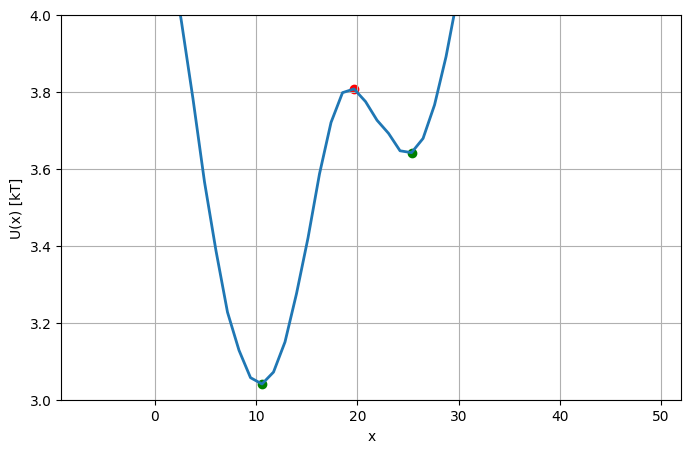

(21.048655136113762, 12.16822098064835)

In [235]:
mfpt_analysis(bin_edges[:-1], U_eff, D = 3000, prominence=0.02, width=3, distance=3) 
